# Предобработка датасета ДТП

In [ ]:
pip install geopandas

In [ ]:
import geopandas as gpd

# Загрузка файла
file_path = 'moskva.geojson'
gdf = gpd.read_file(file_path)

# Посмотрим на данные
print(gdf.head())


        id                                     light  \
0  1540449                       Светлое время суток   
1  1540071                       Светлое время суток   
2  1576658                       Светлое время суток   
3  1534370                       Светлое время суток   
4  2483269  В темное время суток, освещение включено   

                                               point             region  \
0  { "lat": 55.708443000000003, "long": 37.518985...            Раменки   
1  { "lat": 55.793399999999998, "long": 37.576999...        Савеловский   
2   { "lat": 55.803044999999997, "long": 37.407536 }           Строгино   
3  { "lat": 55.825555999999999, "long": 37.646943...       Алексеевский   
4  { "lat": 55.890462999999997, "long": 37.493032...  Западное Дегунино   

  scheme                               address           category  \
0    070        г Москва, пр-кт Мичуринский, 8       Столкновение   
1    720  г Москва, ул Башиловская, 1 корпус 1  Наезд на пешехода   
2    

In [ ]:
# Фильтрация строк и выбор столбцов
filter_data = gdf[gdf['category'] == 'Наезд на пешехода'][['id', 'geometry', 'region', 'severity', 'datetime']]

# Вывод количества строк после фильтрации
print(f"Количество строк с категорией 'Наезд на пешехода': {len(filter_data)}")

# Просмотр первых нескольких строк результирующего DataFrame
print(filter_data.head())

Количество строк с категорией 'Наезд на пешехода': 29695
         id                   geometry             region severity  \
1   1540071     POINT (37.577 55.7934)        Савеловский   Легкий   
2   1576658  POINT (37.40754 55.80304)           Строгино  Тяжёлый   
6   1536171   POINT (37.58286 55.7751)        Пресненский   Легкий   
12  2614503  POINT (37.39657 55.79452)           Строгино  Тяжёлый   
13  2615383  POINT (37.48989 55.77194)  Хорошево-Мневники   Легкий   

              datetime  
1  2018-04-28 13:50:00  
2  2016-09-15 18:23:00  
6  2017-02-03 17:10:00  
12 2021-08-26 21:05:00  
13 2021-08-28 16:37:00  


In [ ]:
import pandas as pd
from datetime import datetime

# Преобразование столбца 'datetime' в формат datetime
filter_data['datetime'] = pd.to_datetime(filter_data['datetime'], format='%Y-%m-%d %H:%M:%S')

# Фильтрация строк с датой ДТП начиная с 2023 года
filtered_data = filter_data[filter_data['datetime'] >= '2023-01-01']

# Вывод количества оставшихся строк
remaining_rows = len(filtered_data)
print(f"Количество строк с ДТП не раньше 2023 года: {remaining_rows}")

# Фильтрация строк по регионам
selected_regions = ["Строгино", "Текстильщики", "Тропарево-Никулино"]
region_filtered_data = filtered_data[filtered_data['region'].isin(selected_regions)]

# Вывод количества строк для каждого региона
region_counts = region_filtered_data['region'].value_counts()
for region, count in region_counts.items():
    print(f"Количество строк в регионе {region}: {count}")

Количество строк с ДТП не раньше 2023 года: 4701
Количество строк в регионе Строгино: 61
Количество строк в регионе Текстильщики: 28
Количество строк в регионе Тропарево-Никулино: 27


In [ ]:
print(region_filtered_data.head())

           id                   geometry              region     severity  \
1675  2836410  POINT (37.46948 55.66493)  Тропарево-Никулино       Легкий   
1734  2836565  POINT (37.73231 55.70106)        Текстильщики      Тяжёлый   
1741  2836574  POINT (37.73026 55.70802)        Текстильщики       Легкий   
1744  2836583  POINT (37.74777 55.70159)        Текстильщики       Легкий   
1972  2915202   POINT (37.46494 55.6778)  Тропарево-Никулино  С погибшими   

                datetime  
1675 2023-05-10 12:02:00  
1734 2023-05-26 08:43:00  
1741 2023-05-19 16:09:00  
1744 2023-05-13 12:30:00  
1972 2023-11-29 06:07:00  


In [ ]:
from shapely.geometry import Point

# Проверка типа данных в столбце 'geometry'
if not isinstance(gdf.loc[0, 'geometry'], Point):  # Проверяем первый элемент как пример
    # Преобразование только если данные в строковом формате
    region_filtered_data['geometry'] = region_filtered_data['geometry'].apply(
        lambda x: Point(map(float, x.strip('POINT ()').split()))
    )

# Убедимся, что GeoDataFrame имеет правильную систему координат
import geopandas as gpd
if not gdf.crs:
    gdf.set_crs(epsg=4326, inplace=True)  # Установить WGS 84 (широта/долгота)

print(region_filtered_data.head())

           id                   geometry              region     severity  \
1675  2836410  POINT (37.46948 55.66493)  Тропарево-Никулино       Легкий   
1734  2836565  POINT (37.73231 55.70106)        Текстильщики      Тяжёлый   
1741  2836574  POINT (37.73026 55.70802)        Текстильщики       Легкий   
1744  2836583  POINT (37.74777 55.70159)        Текстильщики       Легкий   
1972  2915202   POINT (37.46494 55.6778)  Тропарево-Никулино  С погибшими   

                datetime  
1675 2023-05-10 12:02:00  
1734 2023-05-26 08:43:00  
1741 2023-05-19 16:09:00  
1744 2023-05-13 12:30:00  
1972 2023-11-29 06:07:00  


# Создание датасета со светофорами

In [ ]:
# Пример данных
data = {
    "geometry": [
        Point(37.46868, 55.68044), #1
        Point(37.46785, 55.68002), #2
        Point(37.46428, 55.67738), #3
        Point(37.45801, 55.67332), #4
        Point(37.48416, 55.67577), #5
        Point(37.48949, 55.65842), #6
        Point(37.49382, 55.65649), #7
        Point(37.49593, 55.65546), #8
        Point(37.48350, 55.66356), #9
        Point(37.48363, 55.66336), #10
    ],
    "green_timer": [True, True, True, True, True, True, True, True, True, True],
    "red_timer": [False, False, False, False, False, False, False, False, False, False],
    "region": ["Тропарёво-Никулино", "Тропарёво-Никулино", "Тропарёво-Никулино", "Тропарёво-Никулино", "Тропарёво-Никулино", "Тропарёво-Никулино", "Тропарёво-Никулино", "Тропарёво-Никулино", "Тропарёво-Никулино", "Тропарёво-Никулино"],
}

# Создание GeoDataFrame
gdf_lights = gpd.GeoDataFrame(data, crs="EPSG:4326")  # WGS 84


In [ ]:
# Новые данные для добавления
new_data = {
    "geometry": [
        Point(37.48348, 55.66320), #11
        Point(37.48317, 55.66300), #12
        Point(37.48159, 55.65970), #13
        Point(37.48028, 55.65541), #14
        Point(37.47128, 55.66473), #15
        Point(37.48018, 55.66401), #16
        Point(37.48010, 55.66378), #17
        Point(37.48245, 55.66365), #18
        Point(37.46480, 55.66521), #19
        Point(37.46554, 55.65821), #20
        Point(37.46599, 55.65787), #21
        Point(37.47746, 55.65545), #22
        Point(37.47772, 55.65543), #23
        Point(37.47973, 55.65517), #24
        Point(37.47233, 55.65886), #25

    ],
    "green_timer": [True, True, True, True, True, True, True, True, True, True, True, True, True, True, True],
    "red_timer": [False, False, False, False, False, False, False, False, False, False, False, False, False, False, False],
    "region": ["Тропарёво-Никулино", "Тропарёво-Никулино", "Тропарёво-Никулино", "Тропарёво-Никулино", "Тропарёво-Никулино", "Тропарёво-Никулино", "Тропарёво-Никулино", "Тропарёво-Никулино", "Тропарёво-Никулино", "Тропарёво-Никулино", "Тропарёво-Никулино", "Тропарёво-Никулино", "Тропарёво-Никулино", "Тропарёво-Никулино", "Тропарёво-Никулино"],
}

# Создание GeoDataFrame из новых данных
new_records = gpd.GeoDataFrame(new_data, crs=gdf_lights.crs)

# Добавление новых записей к существующему GeoDataFrame
gdf_lights = pd.concat([gdf_lights, new_records], ignore_index=True)



In [ ]:
# Новые данные для добавления
new_data = {
    "geometry": [
        Point(37.47123, 55.65600), #26
        Point(37.47150, 55.65583), #27
        Point(37.47169, 55.65596), #28
        Point(37.47052, 55.65290), #29
        Point(37.46936, 55.64869), #30
        Point(37.50907, 55.66360), #31
        Point(37.50857, 55.66352), #32
        Point(37.50840, 55.66315), #33
        Point(37.49509, 55.65581), #34
        Point(37.46807, 55.64581), #35
        Point(37.46796, 55.64567), #36
        Point(37.44627, 55.66903), #37
        Point(37.44054, 55.66504), #38
        Point(37.45187, 55.67093), #39
    ],
    "green_timer": [True, True, True, True, True, True, True, True, True, True, True, True, True, True],
    "red_timer": [False, False, False, False, False, False, False, False, False, False, False, False, False, False],
    "region": ["Тропарёво-Никулино", "Тропарёво-Никулино", "Тропарёво-Никулино", "Тропарёво-Никулино", "Тропарёво-Никулино", "Тропарёво-Никулино", "Тропарёво-Никулино", "Тропарёво-Никулино", "Тропарёво-Никулино", "Тропарёво-Никулино", "Тропарёво-Никулино", "Тропарёво-Никулино", "Тропарёво-Никулино", "Тропарёво-Никулино"],
}

# Создание GeoDataFrame из новых данных
new_records = gpd.GeoDataFrame(new_data, crs=gdf_lights.crs)

# Добавление новых записей к существующему GeoDataFrame
gdf_lights = pd.concat([gdf_lights, new_records], ignore_index=True)


In [ ]:
# Новые данные для добавления
new_data = {
    "geometry": [
        Point(37.47708, 55.67269), #1
        Point(37.47692, 55.67244), #2
        Point(37.47831, 55.66991), #3
        Point(37.47796, 55.67005), #4
        Point(37.47493, 55.66880), #5
        Point(37.47437, 55.66859), #6
        Point(37.48539, 55.66175), #7
        Point(37.48068, 55.65682), #8
        Point(37.45655, 55.66859), #9
        Point(37.46767, 55.66513), #10
        Point(37.47580, 55.66430), #11
        Point(37.48001, 55.66396), #12
        Point(37.48028, 55.66393), #13
        Point(37.46465, 55.66542), #14
        Point(37.47397, 55.66433), #15
        Point(37.45832, 55.66725), #16
    ],
    "green_timer": [True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True],
    "red_timer": [True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True],
    "region": ["Тропарёво-Никулино", "Тропарёво-Никулино", "Тропарёво-Никулино", "Тропарёво-Никулино", "Тропарёво-Никулино", "Тропарёво-Никулино", "Тропарёво-Никулино", "Тропарёво-Никулино", "Тропарёво-Никулино", "Тропарёво-Никулино", "Тропарёво-Никулино", "Тропарёво-Никулино", "Тропарёво-Никулино", "Тропарёво-Никулино", "Тропарёво-Никулино", "Тропарёво-Никулино"],
}

# Создание GeoDataFrame из новых данных
new_records = gpd.GeoDataFrame(new_data, crs=gdf_lights.crs)

# Добавление новых записей к существующему GeoDataFrame
gdf_lights = pd.concat([gdf_lights, new_records], ignore_index=True)


In [ ]:
# Новые данные для добавления
new_data = {
    "geometry": [
        Point(37.73087, 55.70742), #1
        Point(37.73028, 55.71193), #2
        Point(37.73026, 55.71296), #3
        Point(37.72994, 55.71300), #4
        Point(37.72981, 55.71296), #5
        Point(37.74261, 55.71634), #6
        Point(37.74234, 55.71627), #7
        Point(37.74485, 55.71692), #8
        Point(37.74567, 55.70995), #9
        Point(37.74317, 55.70866), #10
        Point(37.74773, 55.70809), #11
    ],
    "green_timer": [False, True, True, True, True, True, True, True, True, True, True],
    "red_timer": [True, True, False, False, False, True, True, True, True, True, True],
    "region": ["Текстильщики", "Текстильщики", "Текстильщики", "Текстильщики", "Текстильщики", "Текстильщики", "Текстильщики", "Текстильщики", "Текстильщики", "Текстильщики", "Текстильщики"],
}

# Создание GeoDataFrame из новых данных
new_records = gpd.GeoDataFrame(new_data, crs=gdf_lights.crs)

# Добавление новых записей к существующему GeoDataFrame
gdf_lights = pd.concat([gdf_lights, new_records], ignore_index=True)

# Вывод результата
print(gdf_lights)


                     geometry  green_timer  red_timer              region
0   POINT (37.46868 55.68044)         True      False  Тропарёво-Никулино
1   POINT (37.46785 55.68002)         True      False  Тропарёво-Никулино
2   POINT (37.46428 55.67738)         True      False  Тропарёво-Никулино
3   POINT (37.45801 55.67332)         True      False  Тропарёво-Никулино
4   POINT (37.48416 55.67577)         True      False  Тропарёво-Никулино
..                        ...          ...        ...                 ...
61  POINT (37.74234 55.71627)         True       True        Текстильщики
62  POINT (37.74485 55.71692)         True       True        Текстильщики
63  POINT (37.74567 55.70995)         True       True        Текстильщики
64  POINT (37.74317 55.70866)         True       True        Текстильщики
65  POINT (37.74773 55.70809)         True       True        Текстильщики

[66 rows x 4 columns]


In [ ]:
# Новые данные для добавления
new_data = {
    "geometry": [
        Point(37.41587, 55.80479), #1
        Point(37.39277, 55.81369), #2
        Point(37.42003, 55.80427), #3
        Point(37.41587, 55.80479), #4
        Point(37.41339, 55.80534), #5
        Point(37.40850, 55.80280), #6
        Point(37.40820, 55.80237), #7
        Point(37.40758, 55.80147), #8
        Point(37.40595, 55.79976), #9
        Point(37.39880, 55.81238), #10
        Point(37.40417, 55.80990), #11
        Point(37.40805, 55.80726), #12
        Point(37.40766, 55.80299), #13
        Point(37.40786, 55.80139), #14
        Point(37.40663, 55.79946), #15
    ],
    "green_timer": [False, True, True, True, True, True, True, True, True, True, True, True, True, True, True],
    "red_timer": [False, False, False, False, False, False, False, False, False, False, False, False, False, False, False],
    "region": ["Строгино", "Строгино", "Строгино", "Строгино", "Строгино", "Строгино", "Строгино", "Строгино", "Строгино", "Строгино", "Строгино", "Строгино", "Строгино", "Строгино", "Строгино"],
}

# Создание GeoDataFrame из новых данных
new_records = gpd.GeoDataFrame(new_data, crs=gdf_lights.crs)

# Добавление новых записей к существующему GeoDataFrame
gdf_lights = pd.concat([gdf_lights, new_records], ignore_index=True)


In [ ]:
# Новые данные для добавления
new_data = {
    "geometry": [
        Point(37.38359, 55.78928), #16
        Point(37.39291, 55.79247), #17
        Point(37.39055, 55.79242), #18
        Point(37.39002, 55.79238), #19
        Point(37.39440, 55.80583), #20
        Point(37.39564, 55.80760), #21
        Point(37.39722, 55.80998), #22
        Point(37.39839, 55.81170), #23
        Point(37.39299, 55.79636), #24
        Point(37.39742, 55.79452), #25
    ],
    "green_timer": [True, True, True, True, True, True, True, True, True, True],
    "red_timer": [False, False, False, False, False, False, False, False, False, False],
    "region": ["Строгино", "Строгино", "Строгино", "Строгино", "Строгино", "Строгино", "Строгино", "Строгино", "Строгино", "Строгино"],
}

# Создание GeoDataFrame из новых данных
new_records = gpd.GeoDataFrame(new_data, crs=gdf_lights.crs)

# Добавление новых записей к существующему GeoDataFrame
gdf_lights = pd.concat([gdf_lights, new_records], ignore_index=True)

# Вывод результата
print(gdf_lights)

                     geometry  green_timer  red_timer              region
0   POINT (37.46868 55.68044)         True      False  Тропарёво-Никулино
1   POINT (37.46785 55.68002)         True      False  Тропарёво-Никулино
2   POINT (37.46428 55.67738)         True      False  Тропарёво-Никулино
3   POINT (37.45801 55.67332)         True      False  Тропарёво-Никулино
4   POINT (37.48416 55.67577)         True      False  Тропарёво-Никулино
..                        ...          ...        ...                 ...
86   POINT (37.39564 55.8076)         True      False            Строгино
87  POINT (37.39722 55.80998)         True      False            Строгино
88   POINT (37.39839 55.8117)         True      False            Строгино
89  POINT (37.39299 55.79636)         True      False            Строгино
90  POINT (37.39742 55.79452)         True      False            Строгино

[91 rows x 4 columns]


# Анализ

**Плотность населения по районам (на 2018 год):**

*   Строгино: 9500 человек/км^2
*   Тропарёво-Никулоино: 10956 человек/км^2
*   Текстильщики: 17705 человек/км^2




**Площадь районов**

*  Строгино: 16,84 км²
*  Тропарёво-Никулино: 11,26 км²
*  Текстильщики: 5,91 км²





**Численность населения районов**

*   Строгино: 159 980
*   Тропарёво-Никулино: 123 360
*   Текстильщики: 104 640



## Тест 1 -- поиск корреляции между соотношению светофоров с таймером к светофорам без таймера внутри каждого из трёх районов и количеством ДТП в этих районах

Сделаем логичное допущение, что количество дтп с наездом на пешехода прямо пропорционально площади района и квадрату плотности населения (квадрату потому, что при увеличении плотности населения в n раз у нас также возрастает плотность машин в n раз, если мы принимаем прочие параметры равными).

Тогда, если мы принимаем, что районы имеют схожие прочие параметры, мы можем поделить количество ДТП в разных районах на квадрат плотности населения и площадь района и сравнить полученные значения, характеризующие то, как бы отличалось количество ДТП в этих районах, если бы у них была одинаковая площадь и плотность населения.

Из подготовленных выше данных это число для каждого из районов будет следующим:


*   Строгино: 4,01 * 10^-8
*   Тропарёво-Никулино: 2,00 * 10^-8
*   Текстильщики: 1,51 * 10^-8

Ниже приведём график зависимости нашего значения от соотношения светофоров без таймера к общему количеству светофоров

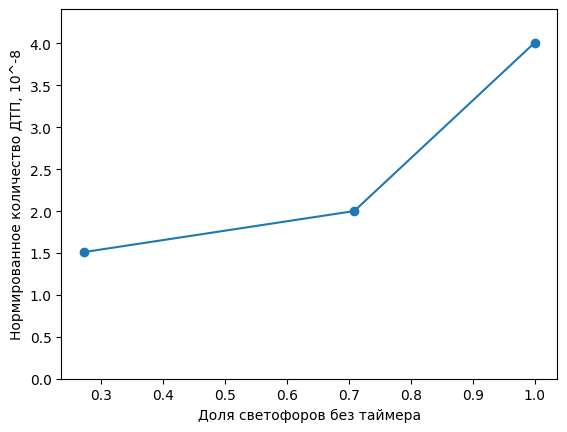

In [ ]:
import matplotlib.pyplot as plt

# Данные для графика
x = [0.273, 0.709, 1]
y = [1.51, 2, 4.01]

# Создание графика
plt.plot(x, y, marker='o')

# Настройка осей и меток
plt.xlabel("Доля светофоров без таймера")
plt.ylabel("Нормированное количество ДТП, 10^-8")
plt.ylim(0, max(y) * 1.1)  # Устанавливаем минимальное значение оси Y равным 0

# Добавление точек на график
for i in range(len(x)):
    plt.annotate(f"", (x[i], y[i]), textcoords="offset points", xytext=(0,10), ha='center')

# Отображение графика
plt.show()

Таким образом, по итогам первого теста можем сделать вывод, что есть положительная корреляция между долей светофоров без таймера и количеством дтп.

Однако, этот вывод сделан на основе предположения, что районы схожи во всём кроме плотности населения и площади. Чтобы проверить полученные результаты, перейдём ко второму тесту, где проведём сравнение между опасностью участков дороги в рамках районов Тропарёво-Никулино и Текстильщики по-отдельности.

## Тест 2 -- сравнение участков дороги вблизи светофоров по двум категориям внутри первых двух районов

Рассмотрим районы Текстильщики и Тропарёво-Никулино по-отдельности. Внутри этих районов распределим произошедшие ДТП по светофорам, около которых они произошли (ДТП будем относить к ближайшему светофору, но если этот светофор расположен не дальше, чем в 20 метрах (или 0,0002 градуса) от местра ДТП). Далее сравним, сколько в среднем ДТП приходится на 1 светофор с таймером и без таймера.

### Текстильщики

In [ ]:
import math

# Функция для расчета расстояния между двумя точками (широта и долгота)
def calculate_distance(lat1, lon1, lat2, lon2):
    return math.sqrt((lat1 - lat2)**2 + (lon1 - lon2)**2)

# Создаем список для хранения результатов
results = []

# Итерируемся по записям в таблице ДТП
for _, crash_row in region_filtered_data.iterrows():
    crash_point = crash_row['geometry']
    crash_lat, crash_lon = crash_point.y, crash_point.x

    # Найти ближайший светофор
    closest_light = None
    closest_distance = float('inf')
    for _, light_row in gdf_lights.iterrows():
        light_point = light_row['geometry']
        light_lat, light_lon = light_point.y, light_point.x

        distance = calculate_distance(crash_lat, crash_lon, light_lat, light_lon)

        # Проверяем, что расстояние минимально и не превышает 0.0002
        if distance < closest_distance and distance <= 0.0002:
            closest_light = light_row
            closest_distance = distance

    # Если нашли подходящий светофор, добавляем запись в результат
    if closest_light is not None:
        results.append({
            'id': crash_row['id'],
            'severity': crash_row['severity'],
            'datetime': crash_row['datetime'],
            'geometry': closest_light['geometry'],
            'red_timer': closest_light['red_timer'],
            'region': closest_light['region']
        })

# Преобразуем результаты в DataFrame
result_df = pd.DataFrame(results)

# Вывод результата
print(result_df)

        id severity            datetime                   geometry  red_timer  \
0  2793395  Тяжёлый 2023-01-28 19:13:00  POINT (37.40805 55.80726)      False   
1  2984557   Легкий 2024-06-01 01:35:00  POINT (37.46868 55.68044)      False   
2  2820478   Легкий 2023-04-21 18:43:00  POINT (37.40766 55.80299)      False   
3  2820705   Легкий 2023-03-11 10:37:00   POINT (37.3944 55.80583)      False   
4  2914828   Легкий 2023-11-07 09:20:00  POINT (37.39722 55.80998)      False   
5  2847304   Легкий 2023-06-14 14:47:00  POINT (37.46868 55.68044)      False   
6  2962350   Легкий 2024-04-05 22:45:00  POINT (37.45801 55.67332)      False   
7  2962366   Легкий 2024-04-02 13:45:00    POINT (37.48317 55.663)      False   
8  2902381  Тяжёлый 2023-10-27 08:15:00  POINT (37.48949 55.65842)      False   

               region  
0            Строгино  
1  Тропарёво-Никулино  
2            Строгино  
3            Строгино  
4            Строгино  
5  Тропарёво-Никулино  
6  Тропарёво-Никулино

Как мы видим, лишь малое количество ДТП произошло вблизи пешеходного светофора. Кроме того, все ДТП, произошедшие в радиусе 20 метров от светофора, произошли около светофоров без таймера.

In [ ]:
import math

# Функция для расчета расстояния между двумя точками (широта и долгота)
def calculate_distance(lat1, lon1, lat2, lon2):
    return math.sqrt((lat1 - lat2)**2 + (lon1 - lon2)**2)

# Создаем список для хранения результатов
results = []

# Итерируемся по записям в таблице ДТП
for _, crash_row in region_filtered_data.iterrows():
    crash_point = crash_row['geometry']
    crash_lat, crash_lon = crash_point.y, crash_point.x

    # Найти ближайший светофор
    closest_light = None
    closest_distance = float('inf')
    for _, light_row in gdf_lights.iterrows():
        light_point = light_row['geometry']
        light_lat, light_lon = light_point.y, light_point.x

        distance = calculate_distance(crash_lat, crash_lon, light_lat, light_lon)

        # Проверяем, что расстояние минимально и не превышает 0.0002
        if distance < closest_distance and distance <= 0.001:
            closest_light = light_row
            closest_distance = distance

    # Если нашли подходящий светофор, добавляем запись в результат
    if closest_light is not None:
        results.append({
            'id': crash_row['id'],
            'severity': crash_row['severity'],
            'datetime': crash_row['datetime'],
            'geometry': closest_light['geometry'],
            'red_timer': closest_light['red_timer'],
            'region': closest_light['region']
        })

# Преобразуем результаты в DataFrame
result_df = pd.DataFrame(results)

# Вывод результата
print(result_df)

         id     severity            datetime                   geometry  \
0   2836574       Легкий 2023-05-19 16:09:00  POINT (37.73087 55.70742)   
1   2915202  С погибшими 2023-11-29 06:07:00  POINT (37.46428 55.67738)   
2   2808911       Легкий 2023-02-22 22:27:00  POINT (37.42003 55.80427)   
3   2793395      Тяжёлый 2023-01-28 19:13:00  POINT (37.40805 55.80726)   
4   2793507       Легкий 2023-01-06 12:43:00  POINT (37.40805 55.80726)   
5   2860183       Легкий 2023-07-03 12:21:00  POINT (37.42003 55.80427)   
6   2984557       Легкий 2024-06-01 01:35:00  POINT (37.46868 55.68044)   
7   2820389       Легкий 2023-04-29 00:01:00  POINT (37.40805 55.80726)   
8   2820408       Легкий 2023-04-27 09:30:00  POINT (37.40805 55.80726)   
9   2820478       Легкий 2023-04-21 18:43:00  POINT (37.40766 55.80299)   
10  2820705       Легкий 2023-03-11 10:37:00   POINT (37.3944 55.80583)   
11  2914828       Легкий 2023-11-07 09:20:00  POINT (37.39722 55.80998)   
12  2915209       Легкий 

Увеличив радиус круга, который мы смотрим вокруг светофора, до 100 метров, у нас появляется в списке первый светофор с таймером в Тропарёво-Никулино и ещё один в Текстильщиках.

Такое незначительное количество ДТП возле светофоров может объясняться тремя факторами:

1.   Вероятность ДТП не на пешеходном переходе выше
2.   Мы собраи не полный набор светофоров и охватили не весь район целиком
3.   Пешеходные светофоры стоят не на всех пешеходных переходах


Первый фактор очевиден и логичен, а для решения второго и третьего нам нужно расширять наше исследование, в том числе охватывать им пешеходные переходы без светофоров, составляя подробную карту ДТП по районам, что в рамках нашего мини исслеования мы сделать не в состоянии.



## Тест 3 -- сравнение участков дороги вблизи светофоров по двум категориям сразу во всех районах. здесь в отличие от второго теста могут сыграть роль различия между районами, но зато увеличивается выборка, по которой идёт сравнение

Из предыдущего блока кода мы видим, что около светофоров без таймера произошло 23 ДТП во всех трёх районах суммарно, а возле светофоров с таймером только 2. Однако это абсолютное значение ДТП без учёта соотношения количества светофоров каждого типа. Если мы посчитаем, сколько ДТП приходится на один светофор каждого типа (число светофоров без таймера 39+3+25=67, а с таймером 16+8=24), мы получим, что на один светофор с таймером приходится 2/24=0,083 ДТП, а на светофор без таймера 23/67=0,343 ДТП. Это ещё раз подтверждает, что (с учётом ограничений нашей выборки) на пешеходных переходах со светофорами без таймеров ДТП происходят чаще примерно в 4 раза.

# Черновики

In [ ]:

import pandas as pd
from shapely.geometry import Point

# Функция для преобразования строки в объект Point
def convert_to_point(geometry_str):
    try:
        coordinates = geometry_str[geometry_str.find("(") + 1:geometry_str.find(")")]
        longitude, latitude = map(float, coordinates.split())
        return Point(longitude, latitude)
    except (ValueError, IndexError):
        return None

# Применение функции к столбцу 'geometry' и создание нового столбца 'geometry_point'
gdf['geometry_point'] = gdf['geometry'].apply(convert_to_point)

# Вывод первых нескольких строк с новым столбцом
print(gdf[['geometry', 'geometry_point']].head())

AttributeError: 'Point' object has no attribute 'find'

In [ ]:
from shapely.geometry import Point

# Создание GeoDataFrame из DataFrame
gdf['geometry'] = gdf['geometry'].apply(lambda x: Point(map(float, x.split(' '))))  # Преобразуем текст в объект Point
geo_data = gpd.GeoDataFrame(gdf, geometry='geometry')

# Проверяем CRS (система координат)
geo_data.set_crs(epsg=4326, inplace=True)  # WGS 84 - стандартная географическая система

AttributeError: 'Point' object has no attribute 'split'

In [ ]:
# prompt: выведи все различные значения ячеек в столбце region из датафрейма gdf

import geopandas as gpd
import pandas as pd
# Assuming gdf is already defined from the previous code

# Display unique values in the 'region' column
unique_regions = gdf['region'].unique()
unique_regions

array(['Раменки', 'Савеловский', 'Строгино', 'Алексеевский',
       'Западное Дегунино', 'Лосиноостровский', 'Пресненский',
       'Москворечье-Сабурово', 'Отрадное', 'Хорошевский', 'Лефортово',
       'Хорошево-Мневники', 'Северное Тушино', 'Покровское-Стрешнево',
       'Сокол', 'Крюково', 'Савёлки', 'Нагорный', 'Тимирязевский',
       'Северный', 'Северное Медведково', 'Ярославский', 'Беговой',
       'Аэропорт', 'Останкинский', 'Лианозово', 'Царицыно',
       'Бабушкинский', 'Чертаново Южное', 'Чертаново Северное',
       'Орехово-Борисово Северное', 'Нагатинский затон', 'Донской',
       'Нагатино-Садовники', 'Даниловский', 'Братеево', 'Южнопортовый',
       'Бирюлево Восточное', 'Бирюлево Западное', 'Нижегородский',
       'Люблино', 'Печатники', 'Кузьминки', 'Некрасовка',
       'Выхино-Жулебино', 'Преображенское', 'Марьино', 'Новокосино',
       'Кокошкино', 'Перово', 'Косино-Ухтомский', 'Соколиная гора',
       'Восточное Измайлово', 'Коньково', 'Котловка', 'Северное Бутово',
